In [2]:
for i in range(10):
    a = input()
    print(a)

a
a
b
a
b
a
b
b
a
b


In [52]:
import numpy as np

class Env:
    colors = ['blue', 'red']


class BernoulliThompsonSamplingAgent(object):
    def __init__(self):
        self.counts = [0 for _ in Env.colors]
        self.likes = [0 for _ in Env.colors]

    @property
    def values(self):
        return np.array([(self.likes[i] + 1) / (self.counts[i] + 2) for i, color in enumerate(Env.colors)])

    def get_color(self):
        beta = lambda N, a: np.random.beta(a + 1, (N - a) + 1)
        result = [beta(self.counts[i], self.likes[i]) for i, color in enumerate(Env.colors)]
        print(result)
        color_idx = np.argmax(result) #result.index(max(result))
        return Env.colors[color_idx]

    def sample(self, color, reward):
        color_idx = Env.colors.index(color)
        self.counts[color_idx] += 1
        self.likes[color_idx] = self.likes[color_idx] + reward

[0.5428659730558218, 0.5301349232451552]
[1, 0], [1, 0]


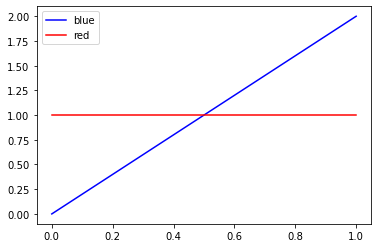

[0.27360411798081463, 0.40318792558675276]
[1, 1], [1, 1]


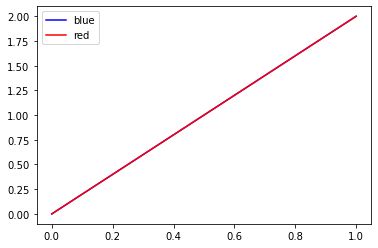

[0.47217870113987875, 0.5245156099405658]
[1, 2], [1, 1]


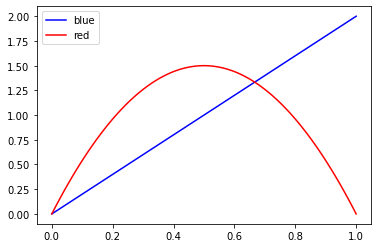

[0.9258857722683551, 0.5248781661930442]
[2, 2], [2, 1]


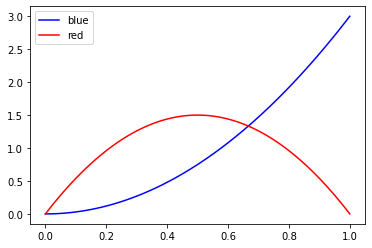

[0.846806644607733, 0.1453915148403516]
[3, 2], [2, 1]


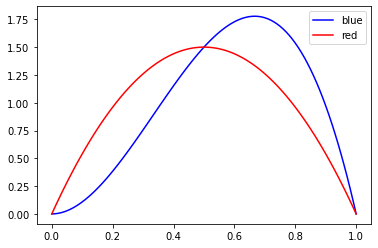

[0.36258224049735327, 0.3820343642006056]
[3, 3], [2, 2]


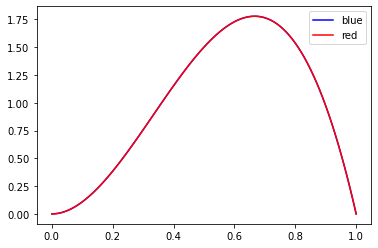

[0.406025081347032, 0.6202121056094543]
[3, 4], [2, 3]


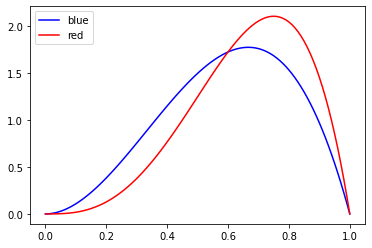

[0.30951166889786647, 0.8465457309744218]
[3, 5], [2, 3]


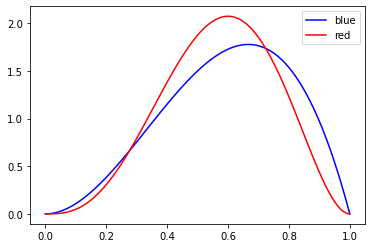

[0.42413135767835936, 0.3667409768823296]
[4, 5], [2, 3]


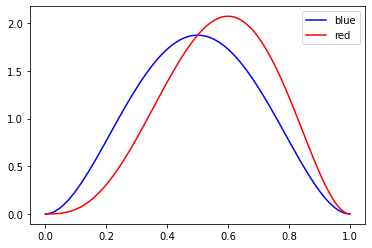

[0.6231867823205174, 0.6547357060946241]
[4, 6], [2, 4]


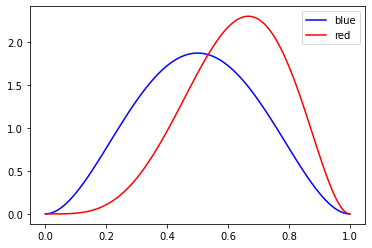

[0.7555106179930001, 0.8208861561325761]
[4, 7], [2, 4]


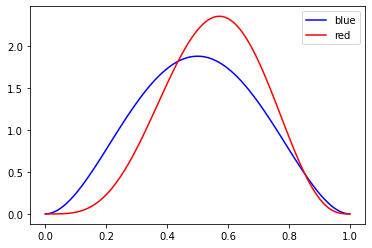

[0.5680203218597968, 0.7570514875124802]
[4, 8], [2, 4]


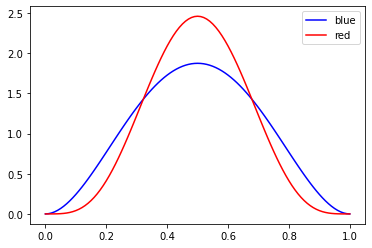

[0.11384350134499022, 0.7533615395348942]
[4, 9], [2, 4]


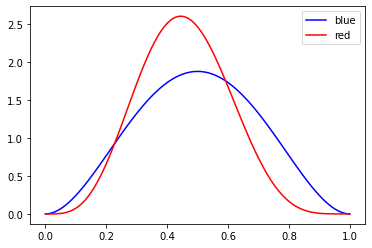

[0.34862236912892575, 0.5897893153459133]
[4, 10], [2, 5]


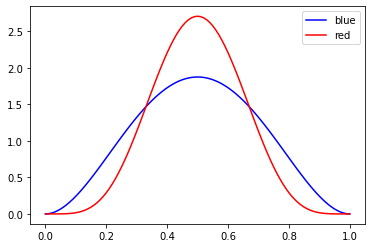

[0.29755524219535434, 0.763561796854155]
[4, 11], [2, 5]


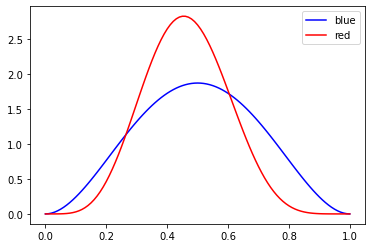

[0.5017805273318241, 0.48725339009676605]
[5, 11], [3, 5]


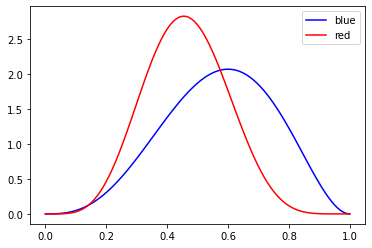

[0.6869291614601312, 0.5175886408723211]
[6, 11], [4, 5]


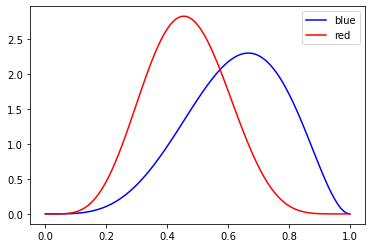

[0.5486003249705493, 0.47743267343325224]
[7, 11], [4, 5]


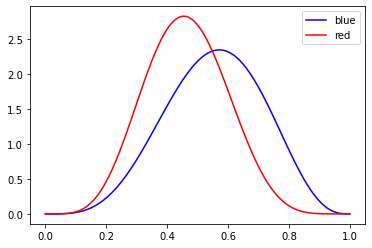

[0.5427494290774232, 0.4916435814320818]
[8, 11], [5, 5]


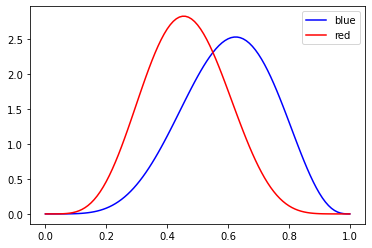

[0.7672452237487619, 0.3874128278657539]
[9, 11], [6, 5]


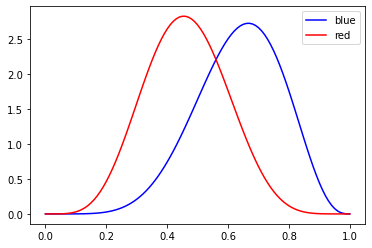

In [54]:
from scipy.stats import beta
import matplotlib.pyplot as plt

agent = BernoulliThompsonSamplingAgent()

N = 20

for i in range(N):
    color = agent.get_color()

    reward = input(f"Do you like {color}? (1: yes, 0: no)")
    reward = int(reward)
    agent.sample(color, reward)
    print(f"{agent.counts}, {agent.likes}")

    x = np.linspace(0, 1, 101)

    for i, color in enumerate(Env.colors):
        a = agent.likes[i] + 1
        b = (agent.counts[i] - agent.likes[i]) + 1
        y = beta.pdf(x, a, b)
        plt.plot(x, y, label=color, color=color)
    plt.legend()
    plt.show()
